## purpose of this

Formally write a validation for the J terms for a single grid, box, and write the M terms

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [32]:
# --- Load edges (bounds) ---
T_edges = rdmds(layers_path + "layers2TH").reshape(-1)    # WAS boundsT (also WAS binsTH_edges)
S_edges = rdmds(layers_path + "layers1SLT").reshape(-1)   # WAS boundsS (also WAS binsSLT_edges)

nT = T_edges.size - 1                                     # WAS nT = binsTH_edges.shape[0]-1
nS = S_edges.size - 1                                     # WAS nS = binsSLT_edges.shape[0]-1

# --- Centers (midpoints between edges) ---
T_centers = 0.5 * (T_edges[:-1] + T_edges[1:])            # WAS binsTH_centers AND WAS binmidT (same quantity)
S_centers = 0.5 * (S_edges[:-1] + S_edges[1:])            # WAS binsSLT_centers AND WAS binmidS (same quantity; you had reshape(nT) bug)

# --- Widths per bin (edge-to-edge) ---
dT_edges = T_edges[1:] - T_edges[:-1]                     # WAS binwidthT
dS_edges = S_edges[1:] - S_edges[:-1]                     # WAS binwidthS

# Optional: "centered widths" (midpoints between adjacent widths)
dT_centers = 0.5 * (dT_edges[:-1] + dT_edges[1:])         # WAS binwidthT1
dS_centers = 0.5 * (dS_edges[:-1] + dS_edges[1:])         # WAS binwidthS1

# --- Inner edges (NOT centers) ---
T_inner_edges = T_edges[1:-1]                             # WAS binmidTp  (you called these "midpoints" but they are interior BOUNDS)
S_inner_edges = S_edges[1:-1]                             # WAS binmidSp  (same: interior BOUNDS, not centers)

# --- 2D grids (meshgrids) ---
T_edges_2d, S_edges_2d = np.meshgrid(T_edges, S_edges)                 # WAS Tbin, Sbin
T_centers_2d, S_centers_2d = np.meshgrid(T_centers, S_centers)         # WAS Tbincent, Sbincent
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)  # WAS Tbin2, Sbin2

# If you need 3D widths broadcasted as (nS, nT, 1)
dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)            # WAS dT, dS from meshgrid(binwidthT, binwidthS)
dT_3d = dT_3d.reshape(nS, nT, 1)                           # WAS dT = dT.reshape(112,112,1) (but use nS,nT not hardcode)
dS_3d = dS_3d.reshape(nS, nT, 1)                           # WAS dS = dS.reshape(112,112,1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]

Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp)

## write our one-point mask and get the J terms

In [5]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [6]:
# create the iwet for a specific, singular column with two cells.
iy,ix = 150,19

In [7]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [8]:
# for any mask, we should be able to do this iwet_mine grabbing and do the J terms

In [9]:
# the overall tend here is different for both. and not sure why. Let's plot an example convergence of T S diagrams from layers
# load the ifldT terms we need from the THETA field
# we are copying from Jy terms

# setTS_Ttend = ['LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS', 'LTto_TS']

# check these from the miniaste if same order
setTS_Ttend=parsemeta(dirlayers + "layers_TSjoint_Ttend_set1.0000000003.meta")["fldList"]
setTS_Ttend

setTS_Stend=parsemeta(dirlayers + "layers_TSjoint_Stend_set1.0000000003.meta")["fldList"]
setTS_Stend

['LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS', 'LSto_TS']

In [10]:
# do the Jy term
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
# JUST FOR SET1 HERE - NOT FOR SET 2
# 287 - should be indexing nt, ns, wetpoints
# T, S, wetpoints
Jy = {}
nbasin = "BarentsS"
# set each basin to its own dictionary
Jy[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)
small = rac2d * hf2d

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jy[nbasin][t] = {}
    Jy[nbasin][t]['G_T'] = {}
    
    # now loop through the terms and add these to the dictionary
    for i in range(len(setTS_Ttend)-1, -1, -1):
        print(i)
        # read the file and apply masking
        filename = dirlayers + f"layers_TSjoint_Ttend_set1.{t}.data"  # check this with new layers dir
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        # if at end of loop
        if i == len(setTS_Ttend)-1:
            f = (np.nansum(tmp, axis=2))
            f = np.nansum(f * binwidthS1)
    
        # double check the names in the listed file
        if i == len(setTS_Ttend)-1:
            # do not remove from the residual - this is the total tendency
            residT = tmp
        elif i in {0,1,2,3,4}:
            # LaTs_TS LaTh_TS LaTz_TS LTha_TS LTza_TS (LTBh_TS)
            # surface forcing, hDiff, vDiff, hADV, vADV, hADV bolus
            residT -= tmp
    
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # SUM OVER WET POINTS - should be of shape nS-1, nT-1
        # TEST:
        # tmp1 = tmp1.T
        tmp2 = np.nansum(tmp1 * binwidthS1,axis=1)              # SUM OVER S - should be of shape nT-1
        Jy[nbasin][t][setTS_Ttend[i]] = tmp1
        Jy[nbasin][t]['G_T'][setTS_Ttend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2


    myresid = np.nansum(residT[:,:,iwet_mine],axis=2)    # SUM OVER WET POINTS - should be of shape nS-1, nT-1
    # myresid = myresid.T
    Jy[nbasin][t]["residT"] = myresid
    Jy[nbasin][t]["G_T"]["residT"] = np.nansum(Jy[nbasin][t]["residT"] * binwidthS1,axis=1)   #SUM OVER S - should be of shape nT-1

    print()
# set units and labels
Jy["unit"] = "m/s/psu"

0000000004
5
4
3
2
1
0



In [11]:
# I think we need to redefine J with a single cell or a very small mask (maybe one cell)
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
Jx = {}
Jx[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jx[nbasin][t] = {}
    Jx[nbasin][t]['G_S'] = {}

    # loop through the diagnostics
    for i in range(len(setTS_Stend)-1, -1, -1):
        filename = dirlayers + f"layers_TSjoint_Stend_set1.{t}.data"
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        print(tmp.shape)
    
        small = rac2d * hf2d
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        if i == len(setTS_Stend)-1:
            # LSto_TS - total tendency
            residS = tmp
        elif i in {0,1,2,3,4}:
            # LaSs_TS LaSh_TS LaSz_TS LSha_TS LSza_TS LSBh_TS
            # surface, hdiff, vdiff, hADV, vADV, hADV bolus
            residS -= tmp
    
        # use stri_wet, strb is names of basins
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # should be of shape nS-1, nT-1
        # TEST
        # tmp1 = tmp1.T
        thisbinwidthT1 = np.tile(binwidthT1[:,np.newaxis],(1, nS - 1))
        tmp2 = np.nansum(tmp1 * thisbinwidthT1, axis=1)                 # second dim is T because this is S tend
        print(setTS_Stend[i])
        Jx[nbasin][t][setTS_Stend[i]] = tmp1
        Jx[nbasin][t]['G_S'][setTS_Stend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2

    tmp1 = np.nansum(residS[:,:,iwet_mine],axis=2)    # sum over geo space
    mytileT1 = np.tile(binwidthT1[np.newaxis,:],(nS-1,1))  # nS-1 x nT-1
    tmp2 = np.nansum(tmp1 * mytileT1, axis=0)     # sum over T ( dimension 0)
    Jx[nbasin][t]["residS"] = tmp1    # should be of shape nS-1, nT-1
    Jx[nbasin][t]["G_S"]["residS"] = tmp2 #should be of shape nT-1

# set units and labels
Jx["descr"] = "m/s/degC"

0000000004
(111, 111, 40500)
LSto_TS
(111, 111, 40500)
LSza_TS
(111, 111, 40500)
LSha_TS
(111, 111, 40500)
LaSz_TS
(111, 111, 40500)
LaSh_TS
(111, 111, 40500)
LaSs_TS


In [17]:
# create the same Jy offline as done before

from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)
termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)


In [19]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [20]:
def bin_3d_term_to_TS(term3d, THETA, SALT, mymsk3d, binmidT, binmidS, binwidthT1, binwidthS1):
    nT = len(binmidT)
    nS = len(binmidS)

    dF_TS = np.zeros((nT-1, nS-1), dtype=float)
    L_TS  = np.zeros((nT-1, nS-1), dtype=int)

    # Flatten
    T_flat = np.ravel(THETA * mymsk3d, order="F")
    S_flat = np.ravel(SALT  * mymsk3d, order="F")
    X_flat = np.ravel(term3d * mymsk3d, order="F")

    # Bin indices
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    # Valid points
    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(X_flat)
    iT = iT[ok]
    iS = iS[ok]
    vals = X_flat[ok]

    # Accumulate
    np.add.at(dF_TS, (iT, iS), vals)
    np.add.at(L_TS,  (iT, iS), 1)

    # Normalize by both bin widths
    dA = binwidthT1[:, None] * binwidthS1[None, :]  # An suggests doing this separately in future
                                                    # first division in dT or dS gets you G_T or G_S
                                                    # second division by dS or dT gets you the J component of J_S or J_T
    G_TS = dF_TS / dA                               # should not be called G_TS here!

    return G_TS, dF_TS, L_TS

termsT_TS = {}
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        binmidT, binmidS, binwidthT1, binwidthS1
    )

termsS_TS = {}
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        binmidT, binmidS, binwidthT1, binwidthS1
    )

In [21]:
for key in list(Jy[nbasin][t].keys())[1:]:
    print(key,np.nansum(Jy[nbasin][t][key]),"Sv/PSU")

LTto_TS -0.01066361855623368 Sv/PSU
LTza_TS 0.0 Sv/PSU
LTha_TS -0.011951185829688696 Sv/PSU
LaTz_TS 0.0 Sv/PSU
LaTh_TS 0.00010078493851158117 Sv/PSU
LaTs_TS 0.00044855824638074816 Sv/PSU
residT 0.000738224088562686 Sv/PSU


In [22]:
for key in list(termsT_TS.keys()):
    print(key,np.nansum(termsT_TS[key])*1e-6,"Sv/PSU")

ADVh -0.011951184761169518 Sv/PSU
ADVr 0.0 Sv/PSU
DFhT 0.00010078492950070633 Sv/PSU
DFrT 0.0 Sv/PSU
surf 0.00044855820627651946 Sv/PSU
KPP 0.0 Sv/PSU
tend -0.011401841625476103 Sv/PSU


In [23]:
# so these are the same and offline is validated

print("Jy term or dG_T/dS") 

resid_ADVh = np.nansum(termsT_TS['ADVh'])*1e-6 - np.nansum(Jy[nbasin][t]['LTha_TS'])
print("resid_ADVh (horizontal advection residual):", resid_ADVh, "Sv/PSU")

resid_DFh = np.nansum(termsT_TS['DFhT'])*1e-6 - np.nansum(Jy[nbasin][t]['LaTh_TS'])
print("resid_DFh (horizontal diffusion residual):", resid_DFh, "Sv/PSU")

resid_surf = np.nansum(termsT_TS['surf'])*1e-6 - np.nansum(Jy[nbasin][t]['LaTs_TS'])
print("resid_surf (surface forcing residual):", resid_surf, "Sv/PSU")

print()

resid_tend = np.nansum(termsT_TS['tend'])*1e-6 - np.nansum(Jy[nbasin][t]['LTto_TS'])
print("resid_tend (tendency residual):", resid_tend, "Sv/PSU")

Jy term or dG_T/dS
resid_ADVh (horizontal advection residual): 1.0685191776521608e-09 Sv/PSU
resid_DFh (horizontal diffusion residual): -9.010874837088456e-12 Sv/PSU
resid_surf (surface forcing residual): -4.0104228694447935e-11 Sv/PSU

resid_tend (tendency residual): -0.0007382230692424222 Sv/PSU


In [24]:
# Do the same for the Jx terms
for key in list(Jx[nbasin][t].keys())[1:]:
    print(key,np.nansum(Jx[nbasin][t][key]),"Sv/degC")

LSto_TS 0.12749151588507307 Sv/degC
LSza_TS 0.0 Sv/degC
LSha_TS 0.20827636172519773 Sv/degC
LaSz_TS 0.0 Sv/degC
LaSh_TS 3.0809382444576085e-06 Sv/degC
LaSs_TS -0.07196190701708625 Sv/degC
residS -0.00882601976128286 Sv/degC


In [25]:
for key in list(termsS_TS.keys()):
    print(key,np.nansum(termsS_TS[key])*1e-6,"Sv/degC")

ADVh 0.20827634310384174 Sv/degC
ADVr 0.0 Sv/degC
DFhS 3.0809379690002897e-06 Sv/degC
DFrS 0.0 Sv/degC
surf -0.07196190058319102 Sv/degC
KPP 0.0 Sv/degC
tend 0.13631752346173268 Sv/degC


In [26]:
# print the residuals here

# print the same comparison of these terms

print("Jx term or dG_S/dT") 

resid_ADVh = np.nansum(termsS_TS['ADVh'])*1e-6 - np.nansum(Jx[nbasin][t]['LSha_TS'])
print("resid_ADVh (horizontal advection residual):", resid_ADVh, "Sv/degC")

resid_DFh = np.nansum(termsS_TS['DFhS'])*1e-6 - np.nansum(Jx[nbasin][t]['LaSh_TS'])
print("resid_DFh (horizontal diffusion residual):", resid_DFh, "Sv/degC")

resid_surf = np.nansum(termsS_TS['surf'])*1e-6 - np.nansum(Jx[nbasin][t]['LaSs_TS'])
print("resid_surf (surface forcing residual):", resid_surf, "Sv/degC")

print()

Jx term or dG_S/dT
resid_ADVh (horizontal advection residual): -1.8621355984960175e-08 Sv/degC
resid_DFh (horizontal diffusion residual): -2.754573188503437e-13 Sv/degC
resid_surf (surface forcing residual): 6.433895236024334e-09 Sv/degC



### plotting the residuals for GS and GT

In [38]:
termsS_TS.keys()

dict_keys(['ADVh', 'ADVr', 'DFhS', 'DFrS', 'surf', 'KPP', 'tend'])

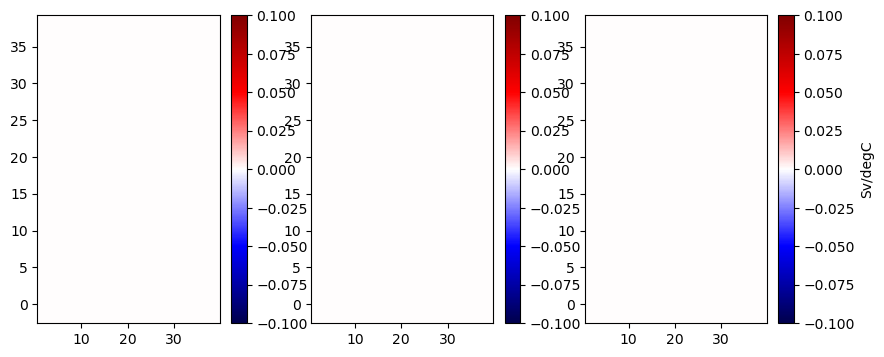

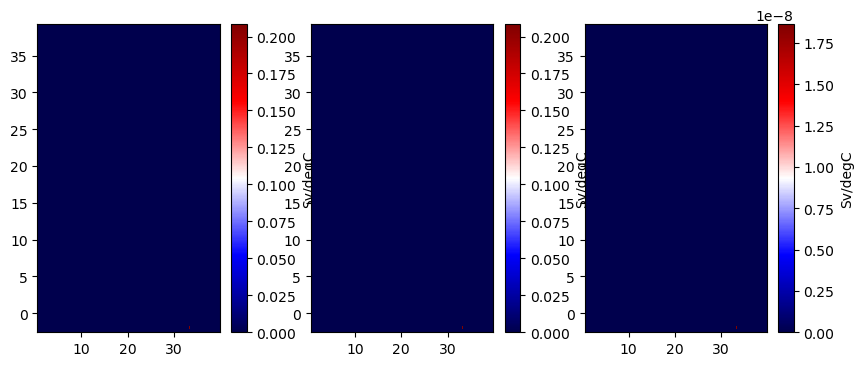

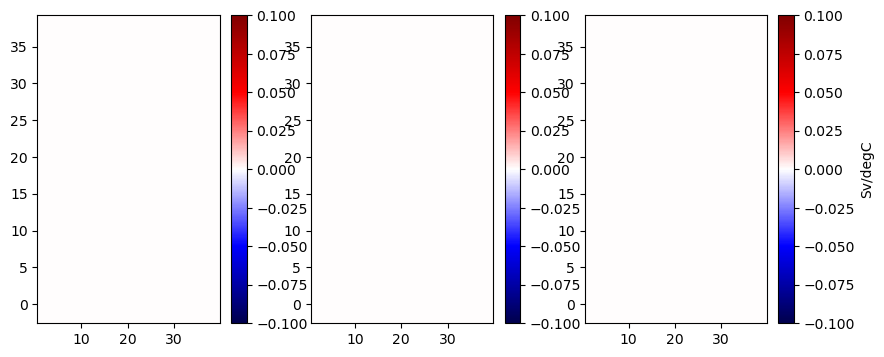

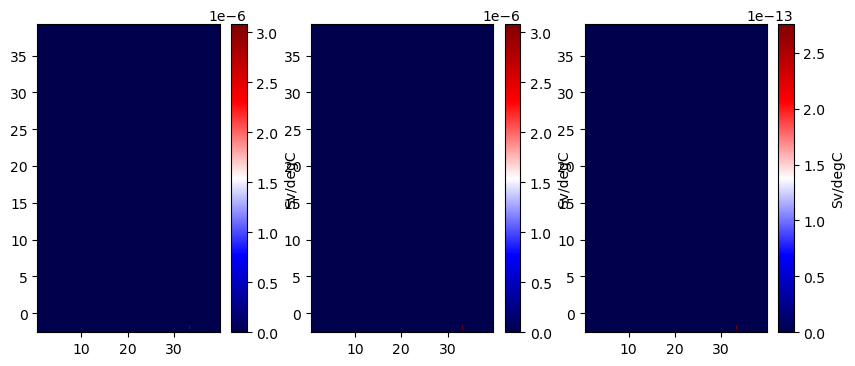

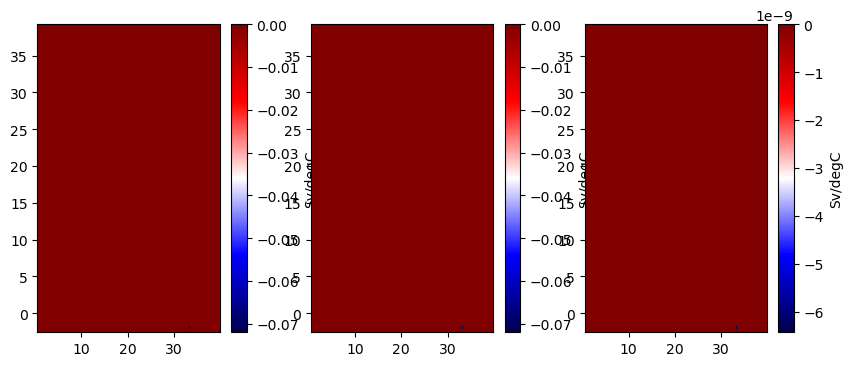

In [41]:
o_off = np.array(['ADVr','ADVh','DFrS','DFhS','surf'])

o = 0  # for indexing in the offline version - this makes no sense but we continue
for key in list(Jx[nbasin][t].keys())[2:-1]:
    # print(key,np.nansum(Jx[nbasin][t][key]),"Sv/degC")

    a = Jx[nbasin][t][key]
    b = termsS_TS[o_off[o]] * 1e-6
    c = a-b

    fig = plt.figure()
    ax = plt.subplot(131)
    cb = ax.pcolormesh(Sbin2,Tbin2,a.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/degC")


    ax = plt.subplot(132)
    cb = ax.pcolormesh(Sbin2,Tbin2,b.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/degC")

    ax = plt.subplot(133)
    cb = ax.pcolormesh(Sbin2,Tbin2,c.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/degC")

    o +=1 

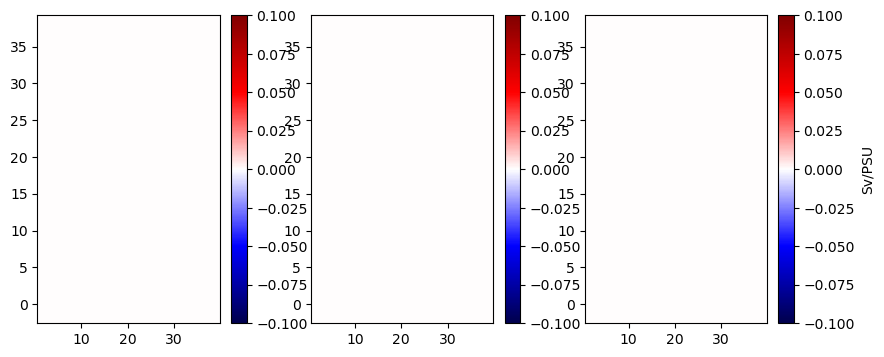

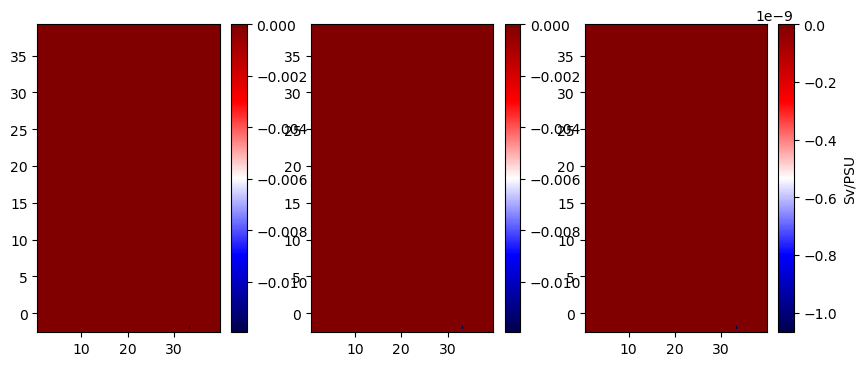

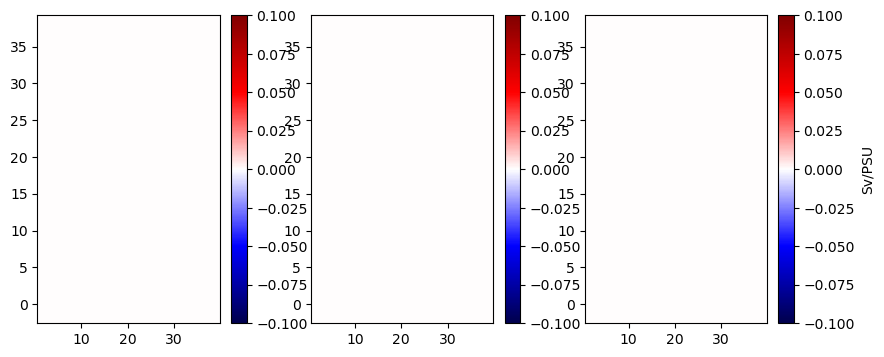

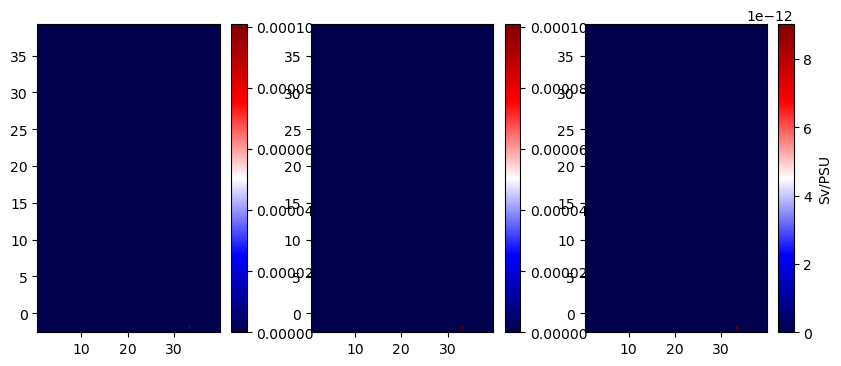

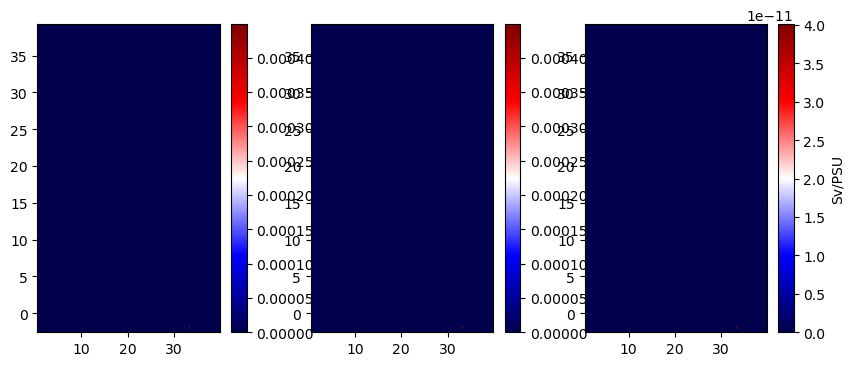

In [43]:
# plot these J vectors side by side here with the layers online diagnostics
# can do a 1x3 for each of the terms

o_off = np.array(['ADVr','ADVh','DFrT','DFhT','surf'])

o = 0  # for indexing in the offline version - this makes no sense but we continue
for key in list(Jy[nbasin][t].keys())[2:-1]:
    # print(key,np.nansum(Jx[nbasin][t][key]),"Sv/degC")

    a = Jy[nbasin][t][key]
    b = termsT_TS[o_off[o]] * 1e-6
    c = a-b

    fig = plt.figure()
    ax = plt.subplot(131)
    cb = ax.pcolormesh(Sbin2,Tbin2,a.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/PSU")


    ax = plt.subplot(132)
    cb = ax.pcolormesh(Sbin2,Tbin2,b.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/PSU")

    ax = plt.subplot(133)
    cb = ax.pcolormesh(Sbin2,Tbin2,c.T,cmap='seismic')
    plt.colorbar(cb,label="Sv/PSU")

    o +=1 

In [44]:
# recall that on top of this the M term will be binned at the faces, not at the cell centers at the basin edges
# therefore it will not be the same